In [10]:
import pyarrow  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

df2 = pd.read_parquet("malaysia_transactions.parquet", engine="pyarrow")
df = df2.head(1000000)

print(f"Shape of top 1M data: {df.shape}")
print(df.head())
df.info()
print(df.describe().T)
df.describe(include='all')  # Use include='object' for categorical
df.nunique().sort_values()

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

Shape of top 1M data: (1000000, 19)
                                trxn_id           date_time  ofi_acct_number  \
0  efa142dd-460e-4a47-928f-00da822cc479 2025-06-26 16:23:10   SB367351043121   
1  a7fcc7f9-644d-4de3-84e0-addcd5472f51 2025-06-26 19:13:24  FSB680204895602   
2  44d41e98-2cc0-4198-8924-e5dccf1f687e 2025-06-28 06:30:10   SB111553054019   
3  43bf8456-349b-4cf4-a40a-b7377a915a67 2025-06-20 14:11:23   SB026082802326   
4  8f7022cd-3450-4686-a299-1ac9a9f0e4d4 2025-06-02 06:39:48   SB553846781254   

         ofi_bank_code   ofi_entity_id ofi_entity_type rfi_acct_number  \
0        Selangor Bank  661119-01-7377        Personal  BS793483278866   
1  First Selangor Bank  670529-02-6381        Personal  BP198107986150   
2        Selangor Bank  891101-07-6618        Personal  BJ991281364892   
3        Selangor Bank  791018-10-7801        Personal  BJ991281364892   
4        Selangor Bank  700624-08-6856        Personal  BJ991281364892   

     rfi_bank_code rfi_entity_id rfi_e

In [ ]:
# # Transaction Frequency Over Time
# df['date_time'] = pd.to_datetime(df['date_time'])
# df.set_index('date_time').resample('H').size().plot()
# Hour-of-Day and Day-of-Week Trends
# df['hour'] = df['date_time'].dt.hour
# df['dayofweek'] = df['date_time'].dt.dayofweek

# # Number of Transactions per Account
# ofi_txns = df['ofi_acct_number'].value_counts()
# rfi_txns = df['rfi_acct_number'].value_counts()

# # Transaction Volume by Entity Type
# df.groupby('ofi_entity_type')['trxn_amount'].sum()

# # Distribution of Amounts (Log-transformed)
# import numpy as np
# import seaborn as sns
# sns.histplot(np.log1p(df['trxn_amount'].astype(float)), bins=100)

#  Account Type Risk Scoring (Mule / Fake Merchant Detection

# account_profile = df.groupby('rfi_acct_number').agg({
#     'trxn_amount': ['count', 'sum', 'mean'],
#     'ofi_acct_number': pd.Series.nunique,
#     'rfi_entity_id': pd.Series.nunique
# })

In [11]:
# Load and prepare data
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Convert datetime and create time features
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6])
df['is_business_hours'] = df['hour'].between(9, 17)

# Convert amount to numeric
df['trxn_amount'] = pd.to_numeric(df['trxn_amount'], errors='coerce')

Dataset shape: (1000000, 19)
Memory usage: 1104.66 MB


If is merchant or business type account, then could ignore, 

In [ ]:
# === MULE ACCOUNT DETECTION FEATURES ===
def calculate_mule_features(df):
    # Account-level aggregations
    ofi_stats = df.groupby('ofi_acct_number').agg({
        'trxn_amount': ['count', 'sum', 'mean', 'std', 'min', 'max'],
        'rfi_acct_number': 'nunique',
        'date_time': ['min', 'max'],
        'hour': lambda x: x.std(),
        'is_weekend': 'sum'
    }).round(2)
    
    rfi_stats = df.groupby('rfi_acct_number').agg({
        'trxn_amount': ['count', 'sum', 'mean', 'std', 'min', 'max'],
        'ofi_acct_number': 'nunique',
        'date_time': ['min', 'max'],
        'hour': lambda x: x.std(),
        'is_weekend': 'sum'
    }).round(2)
    
    # Flatten column names
    ofi_stats.columns = ['_'.join(col).strip() for col in ofi_stats.columns]
    rfi_stats.columns = ['_'.join(col).strip() for col in rfi_stats.columns]
    
    return ofi_stats, rfi_stats

ofi_features, rfi_features = calculate_mule_features(df)

# Calculate account lifespans
ofi_features['account_lifespan_days'] = (ofi_features['date_time_max'] - ofi_features['date_time_min']).dt.days
rfi_features['account_lifespan_days'] = (rfi_features['date_time_max'] - rfi_features['date_time_min']).dt.days

print("=== POTENTIAL MULE INDICATORS ===")
print("OFI accounts with high fan-out (>50 unique senders):")
high_fanout_ofi = ofi_features[ofi_features['rfi_acct_number_nunique'] > 50].sort_values('rfi_acct_number_nunique', ascending=False)
print(f"Found {len(high_fanout_ofi)} accounts")
print(high_fanout_ofi[['trxn_amount_count', 'rfi_acct_number_nunique', 'trxn_amount_sum']].head())

print("\nRFI accounts with high fan-in (>50 unique receivers):")
high_fanin_rfi = rfi_features[rfi_features['ofi_acct_number_nunique'] > 50].sort_values('ofi_acct_number_nunique', ascending=False)
print(f"Found {len(high_fanin_rfi)} accounts")
print(high_fanin_rfi[['trxn_amount_count', 'ofi_acct_number_nunique', 'trxn_amount_sum']].head())

=== POTENTIAL MULE INDICATORS ===
OFI accounts with high fan-out (>50 unique recipients):
Found 34 accounts
                  trxn_amount_count  rfi_acct_number_nunique  trxn_amount_sum
ofi_acct_number                                                              
SB980557410587                19718                     6711        292265.96
SB479496072948                  715                      637        179133.89
KLTB735804688007                586                      586        541298.01
PB847581914279                  571                      555         45800.40
SCB116287595048                 540                      532         73022.88

RFI accounts with high fan-in (>50 unique senders):
Found 440 accounts
                 trxn_amount_count  ofi_acct_number_nunique  trxn_amount_sum
rfi_acct_number                                                             
BS793483278866               64768                    45175       2034044.27
BJ991281364892               62165         

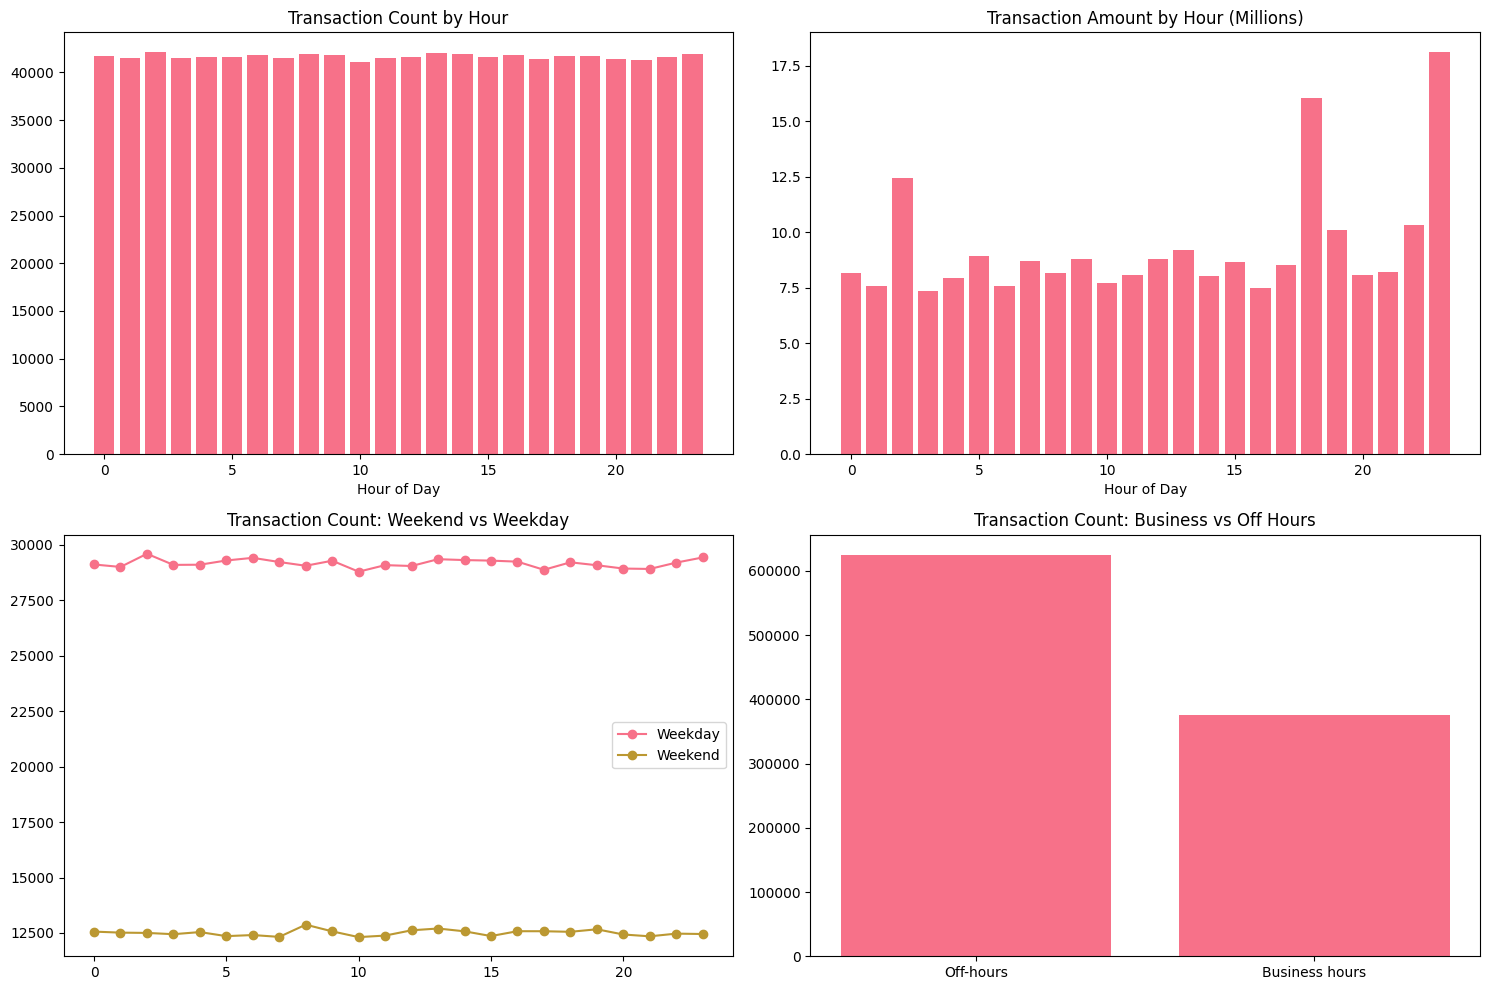

=== TEMPORAL ANOMALIES ===
Off-hours transactions: 62.5%
Weekend transactions: 30.0%


In [ ]:
# === TEMPORAL ANOMALY DETECTION ===
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Transaction volume by hour
hourly_volume = df.groupby('hour')['trxn_amount'].agg(['count', 'sum'])
axes[0,0].bar(hourly_volume.index, hourly_volume['count'])
axes[0,0].set_title('Transaction Count by Hour')
axes[0,0].set_xlabel('Hour of Day')

# Amount distribution by hour
axes[0,1].bar(hourly_volume.index, hourly_volume['sum']/1000000)
axes[0,1].set_title('Transaction Amount by Hour (Millions)')
axes[0,1].set_xlabel('Hour of Day')

# Weekend vs Weekday patterns
weekend_pattern = df.groupby(['is_weekend', 'hour'])['trxn_amount'].agg(['count', 'mean'])
for weekend in [False, True]:
    subset = weekend_pattern.loc[weekend]
    label = 'Weekend' if weekend else 'Weekday'
    axes[1,0].plot(subset.index, subset['count'], label=label, marker='o')
axes[1,0].set_title('Transaction Count: Weekend vs Weekday')
axes[1,0].legend()

# Business hours vs off-hours
bh_stats = df.groupby('is_business_hours')['trxn_amount'].agg(['count', 'mean', 'sum'])
axes[1,1].bar(['Off-hours', 'Business hours'], bh_stats['count'])
axes[1,1].set_title('Transaction Count: Business vs Off Hours')

plt.tight_layout()
plt.show()

# Identify unusual timing patterns - this formula is fcking wierd hahahahahha
print("=== TEMPORAL ANOMALIES ===")
off_hours_pct = (df[~df['is_business_hours']].shape[0] / df.shape[0]) * 100
weekend_pct = (df[df['is_weekend']].shape[0] / df.shape[0]) * 100
print(f"Off-hours transactions: {off_hours_pct:.1f}%")
print(f"Weekend transactions: {weekend_pct:.1f}%")

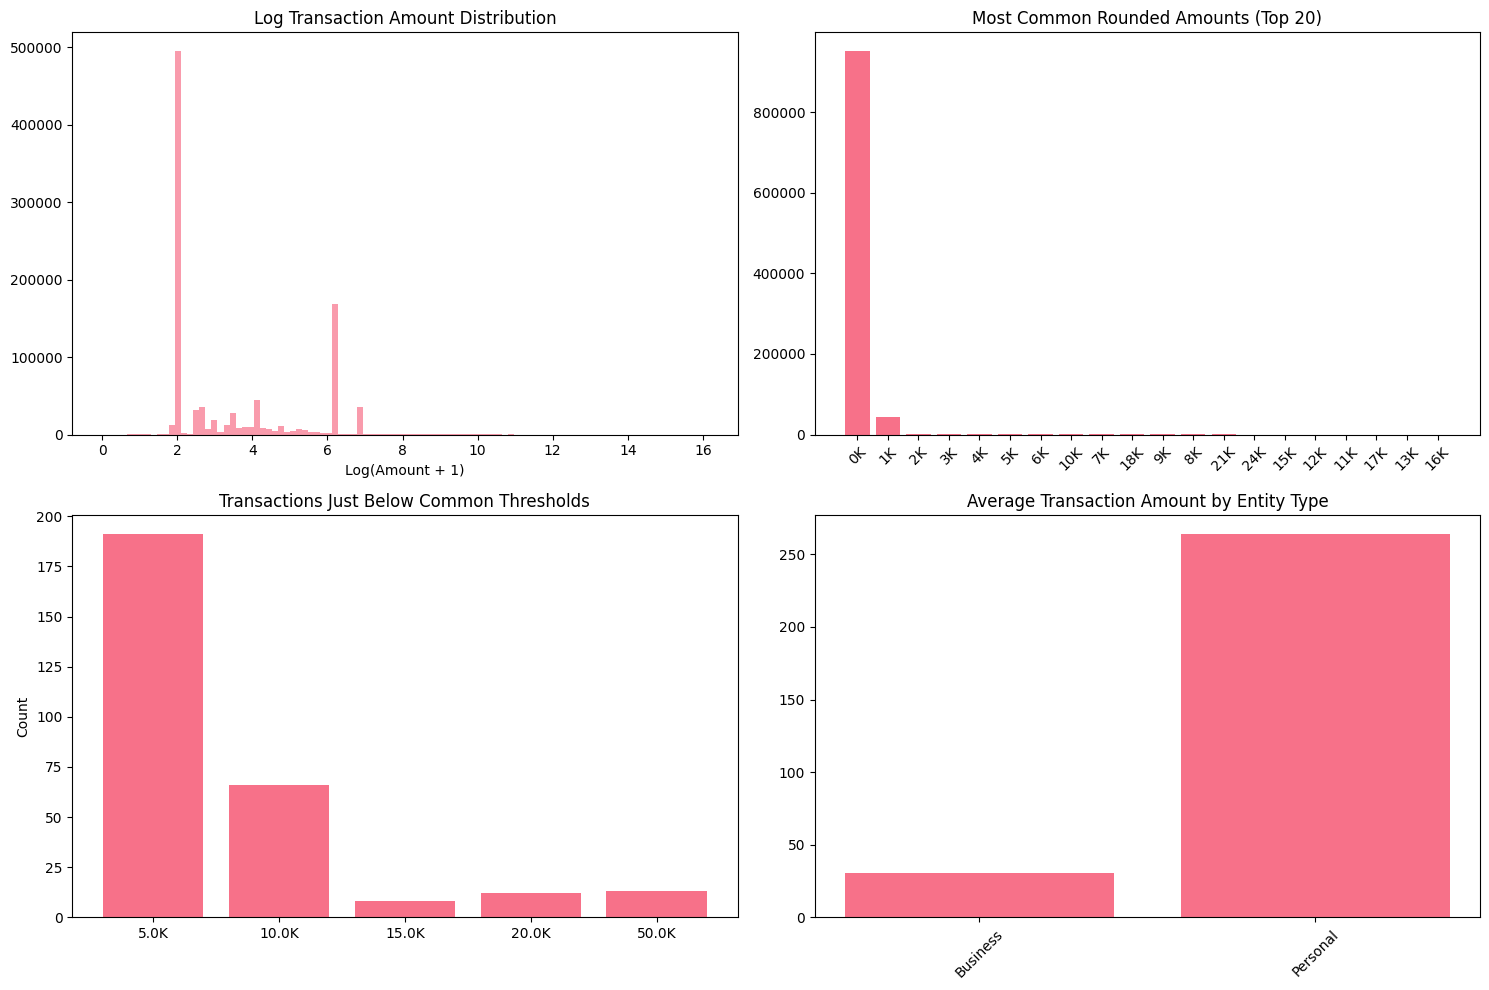

=== AMOUNT-BASED SUSPICIOUS PATTERNS ===
High-value transactions (>99th percentile, ≥900): 43643
Transactions ending in 000: 0.0%
Transactions ending in 5000 or 0000: 0.0%


In [15]:
# === AMOUNT ANOMALY ANALYSIS ===
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Amount distribution (log scale)
axes[0,0].hist(np.log1p(df['trxn_amount']), bins=100, alpha=0.7)
axes[0,0].set_title('Log Transaction Amount Distribution')
axes[0,0].set_xlabel('Log(Amount + 1)')

# Round amount analysis (potential structuring)
df['amount_rounded'] = df['trxn_amount'].round(-3)  # Round to nearest 1000
round_amounts = df['amount_rounded'].value_counts().head(20)
axes[0,1].bar(range(len(round_amounts)), round_amounts.values)
axes[0,1].set_title('Most Common Rounded Amounts (Top 20)')
axes[0,1].set_xticks(range(len(round_amounts)))
axes[0,1].set_xticklabels([f"{int(x/1000)}K" for x in round_amounts.index], rotation=45)

# Identify just-below-threshold amounts (potential structuring)
thresholds = [5000, 10000, 15000, 20000, 50000]
near_threshold_counts = []
for threshold in thresholds:
    near_count = df[(df['trxn_amount'] >= threshold-500) & (df['trxn_amount'] < threshold)].shape[0]
    near_threshold_counts.append(near_count)

axes[1,0].bar([f"{t/1000}K" for t in thresholds], near_threshold_counts)
axes[1,0].set_title('Transactions Just Below Common Thresholds')
axes[1,0].set_ylabel('Count')

# Entity type amount patterns
entity_amounts = df.groupby('ofi_entity_type')['trxn_amount'].agg(['count', 'mean', 'median'])
axes[1,1].bar(entity_amounts.index, entity_amounts['mean'])
axes[1,1].set_title('Average Transaction Amount by Entity Type')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("=== AMOUNT-BASED SUSPICIOUS PATTERNS ===")
# High-value transactions
high_value_threshold = df['trxn_amount'].quantile(0.99)
high_value_txns = df[df['trxn_amount'] >= high_value_threshold]
print(f"High-value transactions (>99th percentile, ≥{high_value_threshold:,.0f}): {len(high_value_txns)}")

# Round number bias
total_txns = len(df)
round_1000_count = len(df[df['trxn_amount'] % 1000 == 0])
round_5000_count = len(df[df['trxn_amount'] % 5000 == 0])
print(f"Transactions ending in 000: {round_1000_count/total_txns*100:.1f}%")
print(f"Transactions ending in 5000 or 0000: {round_5000_count/total_txns*100:.1f}%")

Building transaction network...
Network stats:
Nodes: 1,129,503
Edges: 966,675
Density: 0.000001

Calculating network metrics...


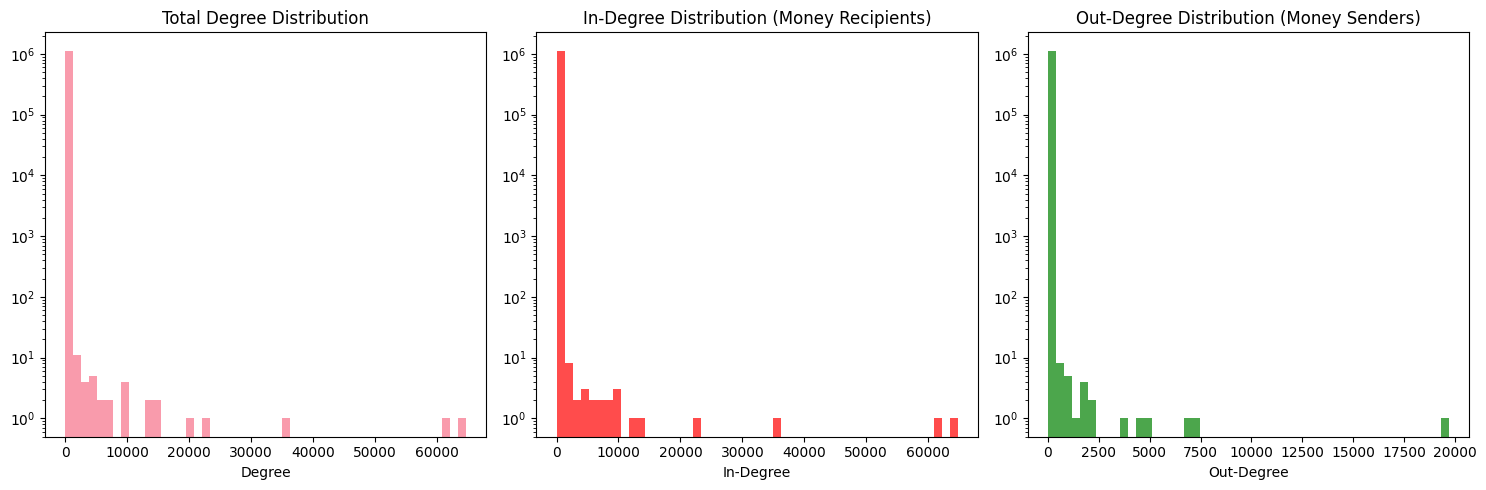


=== POTENTIAL MONEY LAUNDERING PATTERNS ===


KeyboardInterrupt: 

In [ ]:
# # === NETWORK ANALYSIS ===
# # Create transaction network
# print("Building transaction network...")

# # Remove rows with missing account numbers
# df_network = df.dropna(subset=['ofi_acct_number', 'rfi_acct_number'])

# G = nx.from_pandas_edgelist(df_network, source='ofi_acct_number', target='rfi_acct_number', 
#                            edge_attr=['trxn_amount', 'date_time'], create_using=nx.MultiDiGraph())

# print(f"Network stats:")
# print(f"Nodes: {G.number_of_nodes():,}")
# print(f"Edges: {G.number_of_edges():,}")
# print(f"Density: {nx.density(G):.6f}")

# # Calculate network metrics
# print("\nCalculating network metrics...")
# if G.number_of_nodes() < 10000:  # Only for smaller networks due to computational complexity
#     try:
#         centrality_metrics = {
#             'degree_centrality': nx.degree_centrality(G),
#             'in_degree_centrality': nx.in_degree_centrality(G),
#             'out_degree_centrality': nx.out_degree_centrality(G),
#         }
        
#         # Convert to DataFrame for analysis
#         centrality_df = pd.DataFrame(centrality_metrics)
        
#         # Top nodes by different centrality measures
#         print("\n=== NETWORK CENTRALITY ANALYSIS ===")
#         for metric in centrality_metrics.keys():
#             top_nodes = centrality_df.nlargest(5, metric)
#             print(f"\nTop 5 nodes by {metric}:")
#             print(top_nodes[metric])
            
#     except Exception as e:
#         print(f"Centrality calculation failed: {e}")

# # Degree distribution analysis
# degrees = dict(G.degree())
# in_degrees = dict(G.in_degree())
# out_degrees = dict(G.out_degree())

# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# axes[0].hist(list(degrees.values()), bins=50, alpha=0.7)
# axes[0].set_title('Total Degree Distribution')
# axes[0].set_xlabel('Degree')
# axes[0].set_yscale('log')

# axes[1].hist(list(in_degrees.values()), bins=50, alpha=0.7, color='red')
# axes[1].set_title('In-Degree Distribution (Money Recipients)')
# axes[1].set_xlabel('In-Degree')
# axes[1].set_yscale('log')

# axes[2].hist(list(out_degrees.values()), bins=50, alpha=0.7, color='green')
# axes[2].set_title('Out-Degree Distribution (Money Senders)')
# axes[2].set_xlabel('Out-Degree')
# axes[2].set_yscale('log')

# plt.tight_layout()
# plt.show()

# # Identify potential money laundering patterns
# print("\n=== POTENTIAL MONEY LAUNDERING PATTERNS ===")
# high_out_degree = [node for node, degree in out_degrees.items() if degree > np.percentile(list(out_degrees.values()), 95)]
# high_in_degree = [node for node, degree in in_degrees.items() if degree > np.percentile(list(in_degrees.values()), 95)]

# print(f"Accounts with high out-degree (>95th percentile): {len(high_out_degree)}")
# print(f"Accounts with high in-degree (>95th percentile): {len(high_in_degree)}")

# # Find potential intermediary accounts (high both in and out degree)
# intermediaries = set(high_in_degree) & set(high_out_degree)
# print(f"Potential intermediary accounts: {len(intermediaries)}")

=== ENTITY TYPE RISK ANALYSIS ===
                 trxn_amount_count  trxn_amount_sum  trxn_amount_mean  \
ofi_entity_type                                                         
Business                    233011     7.120238e+06             30.56   
Personal                    716805     1.890725e+08            263.77   

                 trxn_amount_std  rfi_acct_number_nunique  \
ofi_entity_type                                             
Business                  120.00                    66617   
Personal                16335.76                   272517   

                 ofi_acct_number_nunique  
ofi_entity_type                           
Business                          221740  
Personal                          581068  

=== POTENTIAL FAKE MERCHANT INDICATORS ===
Entity types with high recipient diversity (potential fake merchants):
                 trxn_amount_count  avg_recipients_per_sender  \
ofi_entity_type                                                 
Personal   

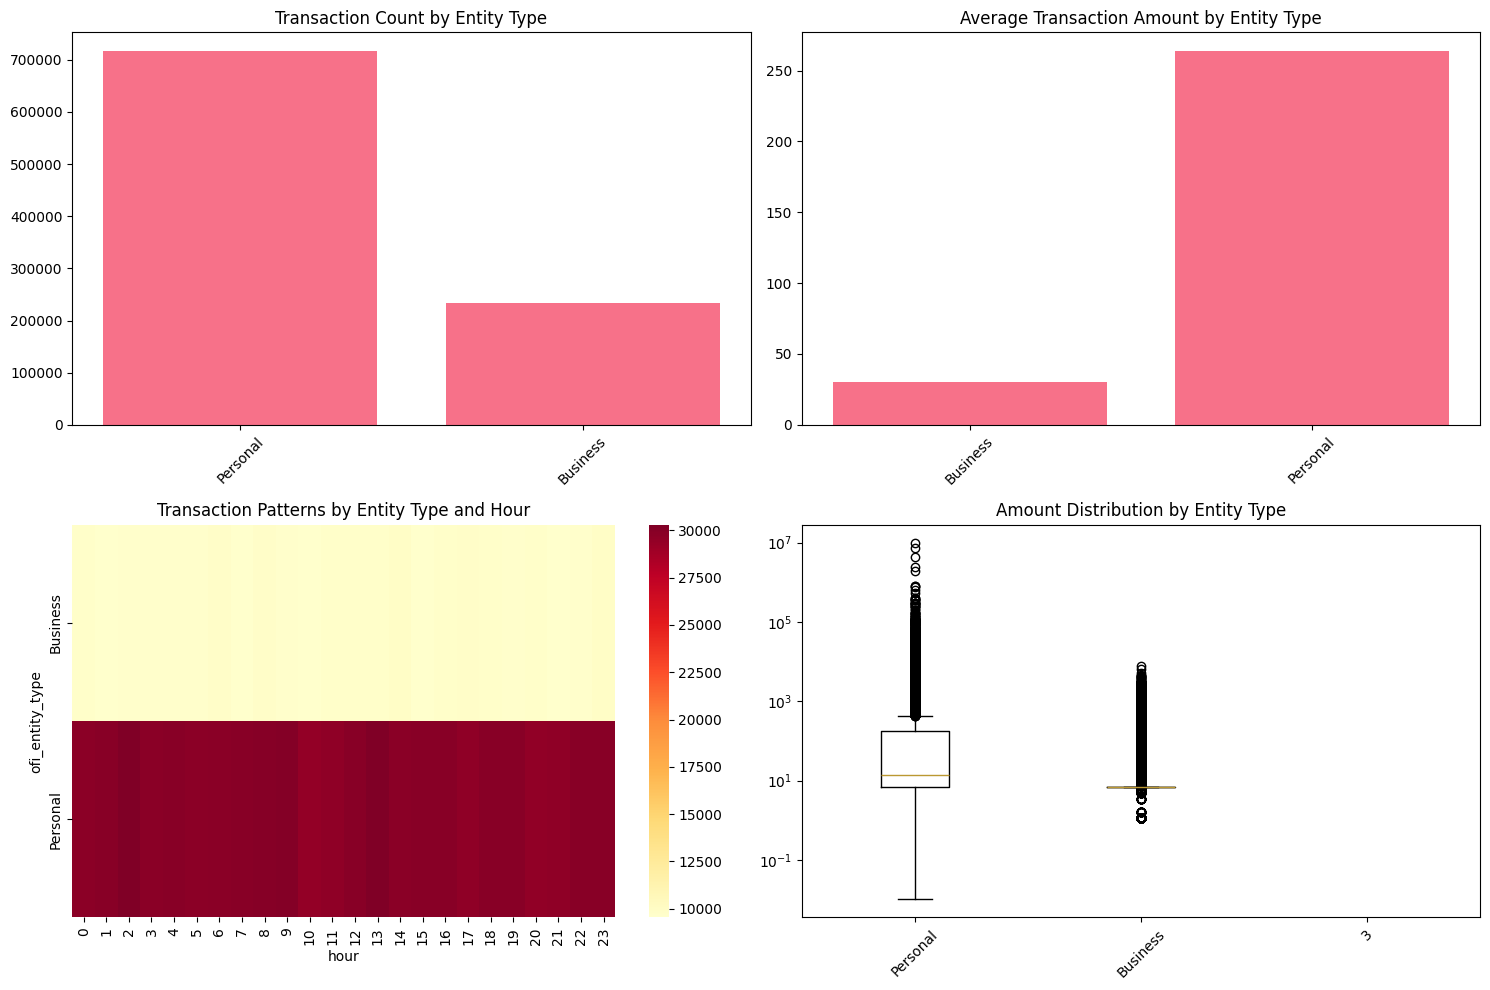

In [16]:
# === ENTITY TYPE ANALYSIS ===
entity_analysis = df.groupby('ofi_entity_type').agg({
    'trxn_amount': ['count', 'sum', 'mean', 'std'],
    'rfi_acct_number': 'nunique',
    'ofi_acct_number': 'nunique'
}).round(2)

entity_analysis.columns = ['_'.join(col).strip() for col in entity_analysis.columns]

print("=== ENTITY TYPE RISK ANALYSIS ===")
print(entity_analysis)

# Calculate risk scores for entity types
entity_analysis['avg_recipients_per_sender'] = entity_analysis['rfi_acct_number_nunique'] / entity_analysis['ofi_acct_number_nunique']
entity_analysis['amount_variability'] = entity_analysis['trxn_amount_std'] / entity_analysis['trxn_amount_mean']

print("\n=== POTENTIAL FAKE MERCHANT INDICATORS ===")
print("Entity types with high recipient diversity (potential fake merchants):")
high_diversity = entity_analysis.sort_values('avg_recipients_per_sender', ascending=False)
print(high_diversity[['trxn_amount_count', 'avg_recipients_per_sender', 'trxn_amount_mean']])

# Visualize entity patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Transaction count by entity type
entity_counts = df['ofi_entity_type'].value_counts()
axes[0,0].bar(range(len(entity_counts)), entity_counts.values)
axes[0,0].set_title('Transaction Count by Entity Type')
axes[0,0].set_xticks(range(len(entity_counts)))
axes[0,0].set_xticklabels(entity_counts.index, rotation=45)

# Average amount by entity type
avg_amounts = df.groupby('ofi_entity_type')['trxn_amount'].mean()
axes[0,1].bar(range(len(avg_amounts)), avg_amounts.values)
axes[0,1].set_title('Average Transaction Amount by Entity Type')
axes[0,1].set_xticks(range(len(avg_amounts)))
axes[0,1].set_xticklabels(avg_amounts.index, rotation=45)

# Entity type vs time pattern
entity_time = df.groupby(['ofi_entity_type', 'hour']).size().unstack(fill_value=0)
sns.heatmap(entity_time, ax=axes[1,0], cmap='YlOrRd')
axes[1,0].set_title('Transaction Patterns by Entity Type and Hour')

# Amount distribution by entity type (box plot)
entity_types = df['ofi_entity_type'].unique()[:5]  # Top 5 for readability
entity_amounts = [df[df['ofi_entity_type'] == et]['trxn_amount'] for et in entity_types]
axes[1,1].boxplot(entity_amounts, labels=entity_types)
axes[1,1].set_title('Amount Distribution by Entity Type')
axes[1,1].set_yscale('log')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# === ENHANCED TRANSACTION PATTERNS ANALYSIS ===

def deep_transaction_analysis(df):
    """Perform comprehensive transaction pattern analysis"""
    
    print("=== DEEP TRANSACTION PATTERNS ANALYSIS ===")
    
    # 1. Transaction velocity analysis by account
    velocity_analysis = df.groupby('ofi_acct_number').agg({
        'date_time': lambda x: (x.max() - x.min()).total_seconds() / 3600 if len(x) > 1 else 0,  # hours
        'trxn_amount': ['count', 'sum', 'mean'],
        'rfi_acct_number': 'nunique'
    })
    velocity_analysis.columns = ['lifespan_hours', 'txn_count', 'total_amount', 'avg_amount', 'unique_recipients']
    velocity_analysis['txns_per_hour'] = velocity_analysis['txn_count'] / (velocity_analysis['lifespan_hours'] + 1)
    velocity_analysis['amount_per_hour'] = velocity_analysis['total_amount'] / (velocity_analysis['lifespan_hours'] + 1)
    
    # High velocity accounts (potential automated/scripted behavior)
    high_velocity = velocity_analysis[velocity_analysis['txns_per_hour'] > velocity_analysis['txns_per_hour'].quantile(0.99)]
    print(f"\nHigh velocity accounts (>99th percentile): {len(high_velocity)}")
    print(high_velocity.head())
    
    # 2. Bank-to-bank flow analysis
    bank_flows = df.groupby(['ofi_bank_code', 'rfi_bank_code']).agg({
        'trxn_amount': ['count', 'sum', 'mean'],
        'ofi_acct_number': 'nunique',
        'rfi_acct_number': 'nunique'
    }).round(2)
    bank_flows.columns = ['txn_count', 'total_amount', 'avg_amount', 'unique_senders', 'unique_recipients']
    
    print(f"\n=== INTER-BANK TRANSACTION FLOWS ===")
    print("Top 10 bank pairs by transaction volume:")
    print(bank_flows.sort_values('total_amount', ascending=False).head(10))
    
    # 3. Entity type cross-flows
    entity_flows = df.groupby(['ofi_entity_type', 'rfi_entity_type']).agg({
        'trxn_amount': ['count', 'sum', 'mean']
    }).round(2)
    entity_flows.columns = ['txn_count', 'total_amount', 'avg_amount']
    
    print(f"\n=== ENTITY TYPE TRANSACTION FLOWS ===")
    print(entity_flows)
    
    return velocity_analysis, bank_flows, entity_flows

# Run deep analysis
velocity_data, bank_data, entity_data = deep_transaction_analysis(df)

=== DEEP TRANSACTION PATTERNS ANALYSIS ===

High velocity accounts (>99th percentile): 198
                 lifespan_hours  txn_count  total_amount  avg_amount  \
ofi_acct_number                                                        
BJ120147790875         0.127500          2         14.00    7.000000   
BJ352700017587       719.525556       1717    1199335.77  698.506564   
BJ516301052420         0.789444          2       1000.00  500.000000   
BJ598119002886         0.757500          2         10.60    5.300000   
BJ810965003655         0.466111          2        146.20   73.100000   

                 unique_recipients  txns_per_hour  amount_per_hour  
ofi_acct_number                                                     
BJ120147790875                   2       1.773836        12.416851  
BJ352700017587                 123       2.382983      1664.529121  
BJ516301052420                   1       1.117665       558.832661  
BJ598119002886                   1       1.137980         6

=== ADVANCED TEMPORAL PATTERN ANALYSIS ===
Off-hours high-value transactions: 30865
Percentage of all high-value txns: 62.6%
Weekend business transactions: 69956


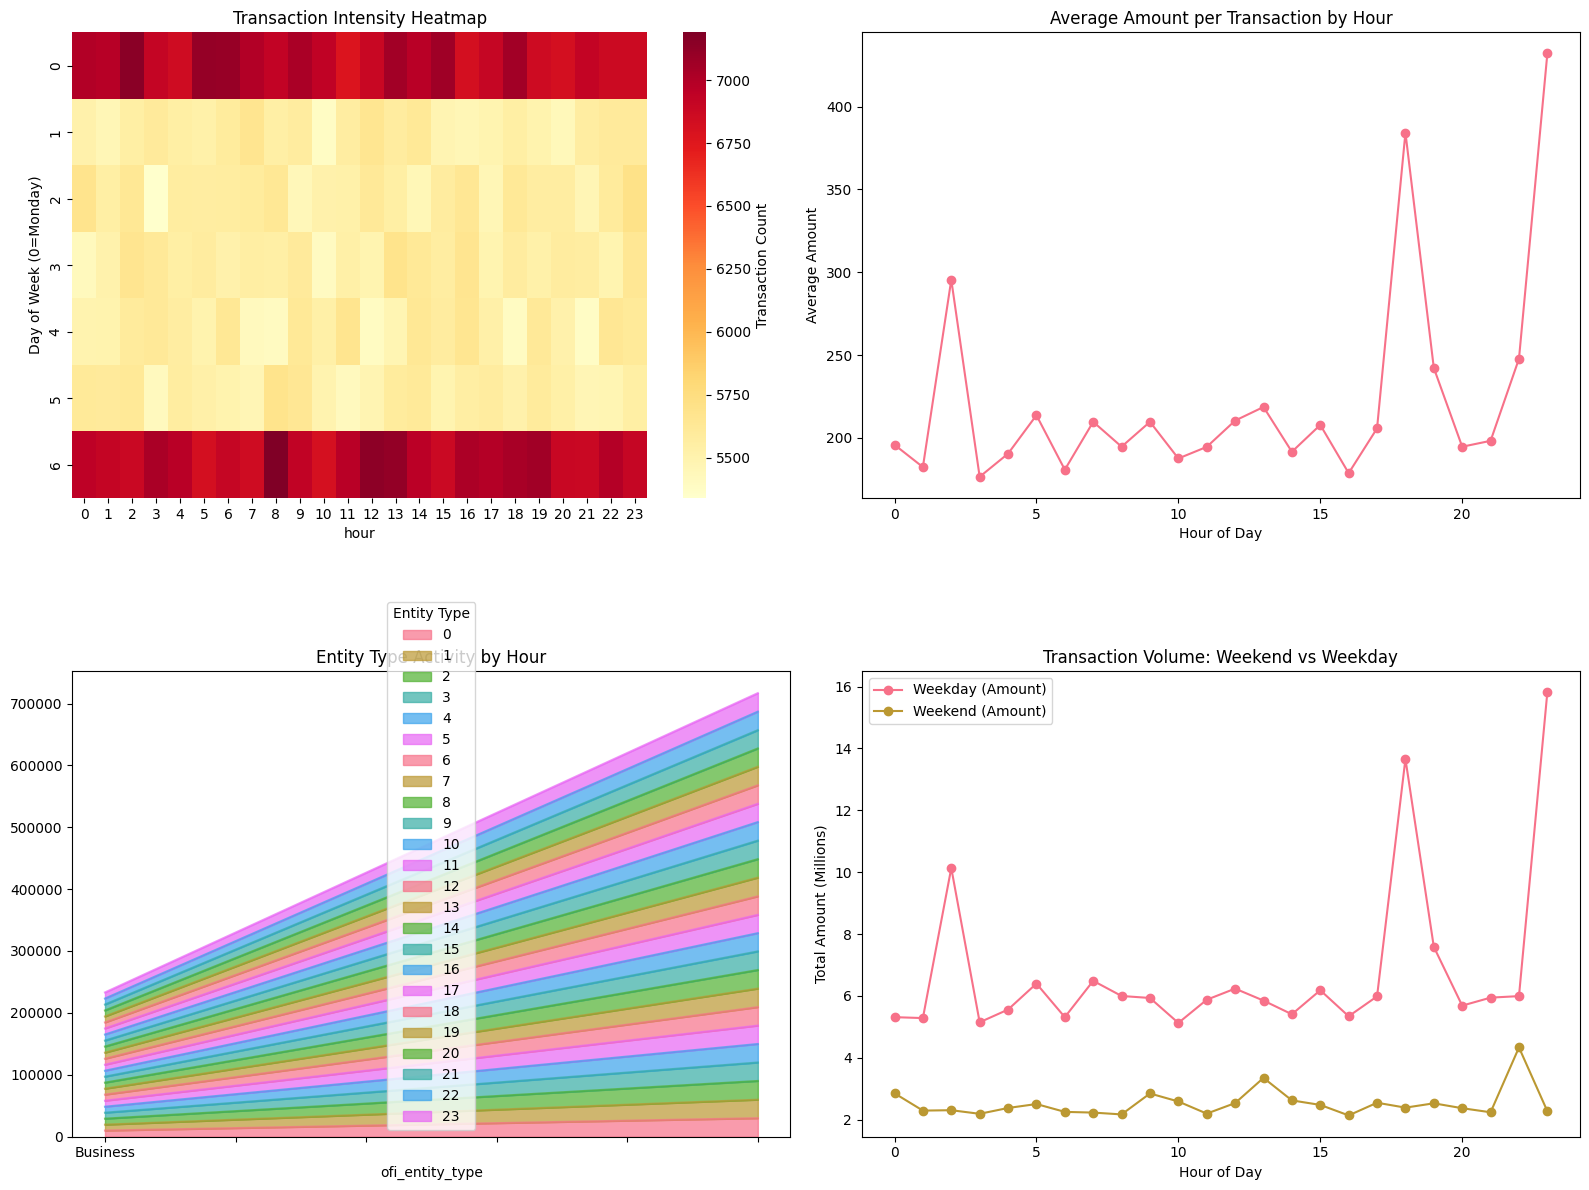

In [18]:
# === ADVANCED TEMPORAL PATTERN ANALYSIS ===

def analyze_temporal_patterns(df):
    """Deep dive into temporal transaction patterns"""
    
    print("=== ADVANCED TEMPORAL PATTERN ANALYSIS ===")
    
    # 1. Hour-by-hour anomaly detection
    hourly_stats = df.groupby('hour').agg({
        'trxn_amount': ['count', 'sum', 'mean', 'std'],
        'ofi_acct_number': 'nunique',
        'rfi_acct_number': 'nunique'
    })
    hourly_stats.columns = ['_'.join(col) for col in hourly_stats.columns]
    
    # Identify unusual hours (low transaction count but high amounts)
    hourly_stats['amount_per_txn'] = hourly_stats['trxn_amount_sum'] / hourly_stats['trxn_amount_count']
    hourly_stats['accounts_ratio'] = hourly_stats['rfi_acct_number_nunique'] / hourly_stats['ofi_acct_number_nunique']
    
    # 2. Day of week patterns
    dow_patterns = df.groupby(['day_of_week', 'hour']).agg({
        'trxn_amount': ['count', 'sum'],
        'ofi_entity_type': lambda x: (x == 'Business').sum()
    })
    
    # 3. Suspicious timing patterns
    # Off-hours high-value transactions
    off_hours_high_value = df[
        (~df['is_business_hours']) & 
        (df['trxn_amount'] > df['trxn_amount'].quantile(0.95))
    ]
    
    print(f"Off-hours high-value transactions: {len(off_hours_high_value)}")
    print(f"Percentage of all high-value txns: {len(off_hours_high_value)/len(df[df['trxn_amount'] > df['trxn_amount'].quantile(0.95)])*100:.1f}%")
    
    # Weekend business transactions
    weekend_business = df[
        (df['is_weekend']) & 
        (df['ofi_entity_type'] == 'Business')
    ]
    
    print(f"Weekend business transactions: {len(weekend_business)}")
    
    # Visualize temporal anomalies
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Hourly transaction intensity heatmap by day of week
    heatmap_data = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
    sns.heatmap(heatmap_data, ax=axes[0,0], cmap='YlOrRd', cbar_kws={'label': 'Transaction Count'})
    axes[0,0].set_title('Transaction Intensity Heatmap')
    axes[0,0].set_ylabel('Day of Week (0=Monday)')
    
    # Amount patterns by hour
    axes[0,1].plot(hourly_stats.index, hourly_stats['amount_per_txn'], marker='o')
    axes[0,1].set_title('Average Amount per Transaction by Hour')
    axes[0,1].set_xlabel('Hour of Day')
    axes[0,1].set_ylabel('Average Amount')
    
    # Entity type timing patterns
    entity_time_patterns = df.groupby(['ofi_entity_type', 'hour']).size().unstack(fill_value=0)
    entity_time_patterns.plot(kind='area', stacked=True, ax=axes[1,0], alpha=0.7)
    axes[1,0].set_title('Entity Type Activity by Hour')
    axes[1,0].legend(title='Entity Type')
    
    # Weekend vs weekday comparison
    weekend_comparison = df.groupby(['is_weekend', 'hour'])['trxn_amount'].agg(['count', 'sum'])
    for is_weekend in [False, True]:
        data = weekend_comparison.loc[is_weekend]
        label = 'Weekend' if is_weekend else 'Weekday'
        axes[1,1].plot(data.index, data['sum']/1000000, label=f'{label} (Amount)', marker='o')
    
    axes[1,1].set_title('Transaction Volume: Weekend vs Weekday')
    axes[1,1].set_xlabel('Hour of Day')
    axes[1,1].set_ylabel('Total Amount (Millions)')
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return hourly_stats, off_hours_high_value, weekend_business

temporal_stats, off_hours_txns, weekend_biz = analyze_temporal_patterns(df)

In [19]:
# === ACCOUNT BEHAVIOR PROFILING ===

def profile_account_behaviors(df):
    """Create detailed behavioral profiles for accounts"""
    
    print("=== ACCOUNT BEHAVIOR PROFILING ===")
    
    # Comprehensive account profiling
    def create_account_profile(account_group, account_type='sender'):
        profile = {
            # Basic statistics
            'total_transactions': len(account_group),
            'total_amount': account_group['trxn_amount'].sum(),
            'avg_amount': account_group['trxn_amount'].mean(),
            'median_amount': account_group['trxn_amount'].median(),
            'amount_std': account_group['trxn_amount'].std(),
            'amount_cv': account_group['trxn_amount'].std() / account_group['trxn_amount'].mean(),
            
            # Temporal patterns
            'active_days': account_group['date_time'].dt.date.nunique(),
            'active_hours': account_group['hour'].nunique(),
            'avg_hour': account_group['hour'].mean(),
            'hour_std': account_group['hour'].std(),
            'weekend_ratio': account_group['is_weekend'].mean(),
            'business_hours_ratio': account_group['is_business_hours'].mean(),
            
            # Network characteristics
            'unique_counterparts': account_group['rfi_acct_number' if account_type == 'sender' else 'ofi_acct_number'].nunique(),
            'counterpart_concentration': account_group['rfi_acct_number' if account_type == 'sender' else 'ofi_acct_number'].value_counts().iloc[0] / len(account_group),
            
            # Transaction patterns
            'amount_range': account_group['trxn_amount'].max() - account_group['trxn_amount'].min(),
            'round_amount_ratio': (account_group['trxn_amount'] % 1000 == 0).mean(),
            'high_value_ratio': (account_group['trxn_amount'] > account_group['trxn_amount'].quantile(0.9)).mean(),
        }
        
        # Lifespan analysis
        if len(account_group) > 1:
            profile['lifespan_days'] = (account_group['date_time'].max() - account_group['date_time'].min()).days
            profile['txns_per_day'] = profile['total_transactions'] / (profile['lifespan_days'] + 1)
            profile['amount_per_day'] = profile['total_amount'] / (profile['lifespan_days'] + 1)
        else:
            profile['lifespan_days'] = 0
            profile['txns_per_day'] = profile['total_transactions']
            profile['amount_per_day'] = profile['total_amount']
        
        return profile
    
    # Profile sender accounts
    sender_profiles = {}
    for account in df['ofi_acct_number'].unique()[:1000]:  # Sample for performance
        account_txns = df[df['ofi_acct_number'] == account]
        sender_profiles[account] = create_account_profile(account_txns, 'sender')
    
    sender_df = pd.DataFrame.from_dict(sender_profiles, orient='index')
    
    # Profile receiver accounts
    receiver_profiles = {}
    for account in df['rfi_acct_number'].dropna().unique()[:1000]:  # Sample for performance
        account_txns = df[df['rfi_acct_number'] == account]
        receiver_profiles[account] = create_account_profile(account_txns, 'receiver')
    
    receiver_df = pd.DataFrame.from_dict(receiver_profiles, orient='index')
    
    # Identify suspicious patterns
    print("=== SUSPICIOUS ACCOUNT PATTERNS ===")
    
    # High velocity, low amount variation (bot-like behavior)
    bot_like = sender_df[
        (sender_df['txns_per_day'] > sender_df['txns_per_day'].quantile(0.95)) &
        (sender_df['amount_cv'] < sender_df['amount_cv'].quantile(0.1))
    ]
    print(f"Potential bot-like accounts: {len(bot_like)}")
    
    # High counterpart concentration (potential mules)
    mule_like = sender_df[
        (sender_df['counterpart_concentration'] > 0.8) &
        (sender_df['total_transactions'] > 10)
    ]
    print(f"Potential mule accounts: {len(mule_like)}")
    
    # Unusual temporal patterns
    odd_timing = sender_df[
        (sender_df['business_hours_ratio'] < 0.2) &
        (sender_df['total_transactions'] > 5)
    ]
    print(f"Accounts with unusual timing patterns: {len(odd_timing)}")
    
    # High-value, low-frequency (potential money laundering)
    high_value_low_freq = sender_df[
        (sender_df['avg_amount'] > sender_df['avg_amount'].quantile(0.95)) &
        (sender_df['txns_per_day'] < sender_df['txns_per_day'].quantile(0.1))
    ]
    print(f"High-value, low-frequency accounts: {len(high_value_low_freq)}")
    
    return sender_df, receiver_df, {
        'bot_like': bot_like,
        'mule_like': mule_like,
        'odd_timing': odd_timing,
        'high_value_low_freq': high_value_low_freq
    }

sender_profiles, receiver_profiles, suspicious_accounts = profile_account_behaviors(df)

=== ACCOUNT BEHAVIOR PROFILING ===
=== SUSPICIOUS ACCOUNT PATTERNS ===
Potential bot-like accounts: 0
Potential mule accounts: 0
Accounts with unusual timing patterns: 1
High-value, low-frequency accounts: 1


In [ ]:
# === AMOUNT PATTERN DEEP DIVE ===

def analyze_amount_patterns(df):
    """Deep analysis of transaction amount patterns"""
    
    print("=== TRANSACTION AMOUNT PATTERN ANALYSIS ===")
    
    # 1. Amount clustering analysis
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    
    # Prepare amount data for clustering
    amount_features = df[['trxn_amount']].copy()
    amount_features['amount_log'] = np.log1p(df['trxn_amount'])
    amount_features['amount_rounded'] = df['trxn_amount'].round(-2)  # Round to nearest 100
    
    # Fit clustering model
    scaler = StandardScaler()
    amount_scaled = scaler.fit_transform(amount_features[['amount_log']])
    
    # Find optimal number of clusters
    inertias = []
    K_range = range(2, 11)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(amount_scaled)
        inertias.append(kmeans.inertia_)
    
    # Use elbow method to select k
    optimal_k = 5  # You can adjust based on elbow plot
    kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    df['amount_cluster'] = kmeans.fit_predict(amount_scaled)
    
    # Analyze clusters
    cluster_analysis = df.groupby('amount_cluster').agg({
        'trxn_amount': ['count', 'min', 'max', 'mean', 'std'],
        'ofi_entity_type': lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'Unknown',
        'is_weekend': 'mean',
        'hour': 'mean'
    })
    
    print("Amount cluster analysis:")
    print(cluster_analysis)
    
    # 2. Benford's Law analysis (first digit distribution)
    def benfords_law_analysis(amounts):
        """Analyze if amounts follow Benford's Law"""
        # Extract first digits
        first_digits = [int(str(int(amount))[0]) for amount in amounts if amount >= 10]
        first_digit_counts = pd.Series(first_digits).value_counts().sort_index()
        
        # Expected Benford's Law distribution
        benford_expected = [np.log10(1 + 1/d) for d in range(1, 10)]
        
        # Actual distribution
        actual_freq = first_digit_counts / first_digit_counts.sum()
        
        return first_digit_counts, actual_freq, benford_expected
    
    first_digits, actual_dist, benford_dist = benfords_law_analysis(df['trxn_amount'])
    
    # 3. Round number analysis
    round_number_analysis = {}
    for threshold in [10, 100, 1000, 5000, 10000]:
        round_count = (df['trxn_amount'] % threshold == 0).sum()
        round_number_analysis[threshold] = {
            'count': round_count,
            'percentage': round_count / len(df) * 100
        }
    
    print("\n=== ROUND NUMBER ANALYSIS ===")
    for threshold, stats in round_number_analysis.items():
        print(f"Amounts divisible by {threshold}: {stats['count']} ({stats['percentage']:.2f}%)")
    
    # 4. Visualizations
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Amount clusters
    for cluster in range(optimal_k):
        cluster_data = df[df['amount_cluster'] == cluster]['trxn_amount']
        axes[0,0].hist(cluster_data, alpha=0.6, label=f'Cluster {cluster}', bins=50)
    axes[0,0].set_title('Amount Clusters')
    axes[0,0].set_xlabel('Transaction Amount')
    axes[0,0].set_yscale('log')
    axes[0,0].legend()
    
    # Benford's Law comparison
    digits = range(1, 10)
    axes[0,1].bar([d-0.2 for d in digits], benford_dist, width=0.4, label='Benford Expected', alpha=0.7)
    axes[0,1].bar([d+0.2 for d in digits], [actual_dist.get(d, 0) for d in digits], width=0.4, label='Actual', alpha=0.7)
    axes[0,1].set_title("Benford's Law Analysis")
    axes[0,1].set_xlabel('First Digit')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].legend()
    
    # Amount distribution by entity type
    df.boxplot(column='trxn_amount', by='ofi_entity_type', ax=axes[0,2])
    axes[0,2].set_title('Amount Distribution by Entity Type')
    axes[0,2].set_yscale('log')
    
    # Round number patterns
    round_thresholds = list(round_number_analysis.keys())
    round_percentages = [round_number_analysis[t]['percentage'] for t in round_thresholds]
    axes[1,0].bar(range(len(round_thresholds)), round_percentages)
    axes[1,0].set_title('Round Number Patterns')
    axes[1,0].set_xticks(range(len(round_thresholds)))
    axes[1,0].set_xticklabels(round_thresholds)
    axes[1,0].set_ylabel('Percentage of Transactions')
    
    # Amount vs time correlation
    df['hour_amount'] = df.groupby('hour')['trxn_amount'].transform('mean')
    axes[1,1].scatter(df['hour'], df['trxn_amount'], alpha=0.1, s=1)
    axes[1,1].plot(range(24), [df[df['hour']==h]['trxn_amount'].mean() for h in range(24)], 'r-', linewidth=2)
    axes[1,1].set_title('Amount vs Hour Patterns')
    axes[1,1].set_xlabel('Hour of Day')
    axes[1,1].set_ylabel('Transaction Amount')
    axes[1,1].set_yscale('log')
    
    # Amount percentile analysis
    percentiles = [50, 75, 90, 95, 99, 99.9]
    amounts = [df['trxn_amount'].quantile(p/100) for p in percentiles]
    axes[1,2].plot(percentiles, amounts, marker='o')
    axes[1,2].set_title('Amount Percentile Distribution')
    axes[1,2].set_xlabel('Percentile')
    axes[1,2].set_ylabel('Amount')
    axes[1,2].set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    return cluster_analysis, first_digits, round_number_analysis

amount_clusters, benford_analysis, round_patterns = analyze_amount_patterns(df)

In [ ]:
# === NETWORK TOPOLOGY DEEP ANALYSIS ===

def deep_network_analysis(df):
    """Advanced network topology analysis"""
    
    print("=== DEEP NETWORK TOPOLOGY ANALYSIS ===")
    
    # Create enhanced network with transaction aggregation
    network_df = df.groupby(['ofi_acct_number', 'rfi_acct_number']).agg({
        'trxn_amount': ['count', 'sum', 'mean', 'std'],
        'date_time': ['min', 'max'],
        'is_weekend': 'mean',
        'hour': lambda x: list(x)  # Keep all hours for analysis
    }).reset_index()
    
    # Flatten columns
    network_df.columns = ['_'.join(col).strip() if col[1] else col[0] for col in network_df.columns]
    
    # Calculate edge features
    network_df['relationship_strength'] = network_df['trxn_amount_count'] * network_df['trxn_amount_mean']
    network_df['lifespan_days'] = (pd.to_datetime(network_df['date_time_max']) - 
                                   pd.to_datetime(network_df['date_time_min'])).dt.days
    network_df['frequency'] = network_df['trxn_amount_count'] / (network_df['lifespan_days'] + 1)
    
    # Build weighted network
    G_weighted = nx.from_pandas_edgelist(
        network_df,
        source='ofi_acct_number',
        target='rfi_acct_number', 
        edge_attr=['relationship_strength', 'trxn_amount_sum', 'frequency'],
        create_using=nx.DiGraph()
    )
    
    print(f"Weighted network: {G_weighted.number_of_nodes()} nodes, {G_weighted.number_of_edges()} edges")
    
    # Network motif analysis (small subgraph patterns)
    motifs = {
        'triangles': 0,
        'mutual_pairs': 0,
        'chains_of_3': 0,
        'stars_out': 0,
        'stars_in': 0
    }
    
    # Sample nodes for motif analysis (computational efficiency)
    sample_nodes = list(G_weighted.nodes())[:1000] if len(G_weighted.nodes()) > 1000 else list(G_weighted.nodes())
    
    for node in sample_nodes:
        out_neighbors = set(G_weighted.successors(node))
        in_neighbors = set(G_weighted.predecessors(node))
        
        # Count mutual connections
        mutual = out_neighbors & in_neighbors
        motifs['mutual_pairs'] += len(mutual)
        
        # Count out-star patterns
        if len(out_neighbors) >= 3:
            motifs['stars_out'] += 1
            
        # Count in-star patterns  
        if len(in_neighbors) >= 3:
            motifs['stars_in'] += 1
    
    print("Network motif analysis:")
    for motif, count in motifs.items():
        print(f"  {motif}: {count}")
    
    # Community detection
    try:
        # Convert to undirected for community detection
        G_undirected = G_weighted.to_undirected()
        
        # Use Louvain method for community detection
        import networkx.algorithms.community as nx_comm
        communities = list(nx_comm.greedy_modularity_communities(G_undirected))
        
        print(f"\nCommunity detection:")
        print(f"Number of communities: {len(communities)}")
        print(f"Largest community size: {max(len(c) for c in communities)}")
        print(f"Average community size: {np.mean([len(c) for c in communities]):.1f}")
        
        # Identify cross-community transactions (potential layering)
        community_map = {}
        for i, community in enumerate(communities):
            for node in community:
                community_map[node] = i
        
        cross_community_edges = 0
        for edge in G_weighted.edges():
            if community_map.get(edge[0]) != community_map.get(edge[1]):
                cross_community_edges += 1
        
        print(f"Cross-community transactions: {cross_community_edges} ({cross_community_edges/G_weighted.number_of_edges()*100:.1f}%)")
        
    except Exception as e:
        print(f"Community detection failed: {e}")
        communities = []
    
    # Hub analysis
    degree_centrality = nx.degree_centrality(G_weighted)
    betweenness_centrality = nx.betweenness_centrality(G_weighted, k=min(1000, G_weighted.number_of_nodes()))
    
    # Identify different types of hubs
    hub_analysis = pd.DataFrame({
        'degree_centrality': degree_centrality,
        'betweenness_centrality': betweenness_centrality,
        'in_degree': dict(G_weighted.in_degree()),
        'out_degree': dict(G_weighted.out_degree())
    })
    
    # Classify hub types
    hub_analysis['hub_type'] = 'normal'
    hub_analysis.loc[
        (hub_analysis['out_degree'] > hub_analysis['out_degree'].quantile(0.95)) &
        (hub_analysis['in_degree'] < hub_analysis['in_degree'].quantile(0.5)), 'hub_type'
    ] = 'distributor_hub'
    
    hub_analysis.loc[
        (hub_analysis['in_degree'] > hub_analysis['in_degree'].quantile(0.95)) &
        (hub_analysis['out_degree'] < hub_analysis['out_degree'].quantile(0.5)), 'hub_type'
    ] = 'collector_hub'
    
    hub_analysis.loc[
        (hub_analysis['betweenness_centrality'] > hub_analysis['betweenness_centrality'].quantile(0.95)), 'hub_type'
    ] = 'bridge_hub'
    
    print(f"\nHub type analysis:")
    print(hub_analysis['hub_type'].value_counts())
    
    return G_weighted, network_df, hub_analysis, communities

enhanced_network, network_features, hub_data, community_data = deep_network_analysis(df)

=== DEEP NETWORK TOPOLOGY ANALYSIS ===
Weighted network: 1129503 nodes, 860335 edges
Network motif analysis:
  triangles: 0
  mutual_pairs: 94
  chains_of_3: 0
  stars_out: 16
  stars_in: 109


In [ ]:
# === FRAUD RISK SCORING SYSTEM ===

def create_fraud_risk_scores(df, sender_profiles, receiver_profiles, hub_data):
    """Create comprehensive fraud risk scoring system"""
    
    print("=== COMPREHENSIVE FRAUD RISK SCORING ===")
    
    # Initialize risk scores
    account_risk_scores = {}
    
    # 1. Behavioral Risk Score
    def calculate_behavioral_risk(profile):
        risk = 0
        
        # High transaction velocity
        if profile.get('txns_per_day', 0) > 50:
            risk += 30
        elif profile.get('txns_per_day', 0) > 20:
            risk += 15
            
        # Unusual timing patterns
        if profile.get('business_hours_ratio', 1) < 0.3:
            risk += 20
            
        # High counterpart concentration (mule behavior)
        if profile.get('counterpart_concentration', 0) > 0.8:
            risk += 25
            
        # Low amount variation (bot-like)
        if profile.get('amount_cv', 1) < 0.1:
            risk += 20
            
        # High round number usage
        if profile.get('round_amount_ratio', 0) > 0.5:
            risk += 15
            
        return min(risk, 100)  # Cap at 100
    
    # 2. Network Risk Score
    def calculate_network_risk(account, hub_data):
        risk = 0
        
        if account in hub_data.index:
            hub_info = hub_data.loc[account]
            
            # High centrality accounts
            if hub_info['degree_centrality'] > 0.01:
                risk += 25
                
            # Bridge accounts (high betweenness)
            if hub_info['betweenness_centrality'] > 0.001:
                risk += 20
                
            # Distributor hubs (potential money laundering)
            if hub_info['hub_type'] == 'distributor_hub':
                risk += 30
            elif hub_info['hub_type'] == 'bridge_hub':
                risk += 25
                
        return min(risk, 100)
    
    # 3. Amount Risk Score  
    def calculate_amount_risk(account_data):
        risk = 0
        
        # High-value transactions
        high_value_ratio = (account_data['trxn_amount'] > account_data['trxn_amount'].quantile(0.95)).mean()
        if high_value_ratio > 0.1:
            risk += 20
            
        # Just-below-threshold amounts
        threshold_amounts = [9000, 9500, 9900]  # Common AML thresholds
        for threshold in threshold_amounts:
            near_threshold = ((account_data['trxn_amount'] >= threshold-100) & 
                            (account_data['trxn_amount'] < threshold)).mean()
            if near_threshold > 0.05:
                risk += 15
                break
                
        return min(risk, 100)
    
    # Calculate scores for each account
    for account in df['ofi_acct_number'].unique()[:5000]:  # Sample for performance
        account_txns = df[df['ofi_acct_number'] == account]
        
        # Get profile if available
        profile = sender_profiles.loc[account] if account in sender_profiles.index else {}
        
        # Calculate component scores
        behavioral_risk = calculate_behavioral_risk(profile)
        network_risk = calculate_network_risk(account, hub_data)
        amount_risk = calculate_amount_risk(account_txns)
        
        # Combined risk score (weighted average)
        total_risk = (behavioral_risk * 0.4 + network_risk * 0.35 + amount_risk * 0.25)
        
        account_risk_scores[account] = {
            'behavioral_risk': behavioral_risk,
            'network_risk': network_risk, 
            'amount_risk': amount_risk,
            'total_risk': total_risk,
            'risk_category': 'High' if total_risk >= 70 else 'Medium' if total_risk >= 40 else 'Low'
        }
    
    # Convert to DataFrame
    risk_df = pd.DataFrame.from_dict(account_risk_scores, orient='index')
    
    # Risk distribution analysis
    print("Risk score distribution:")
    print(risk_df['risk_category'].value_counts())
    print(f"\nAverage scores:")
    print(risk_df[['behavioral_risk', 'network_risk', 'amount_risk', 'total_risk']].mean())
    
    # High-risk accounts
    high_risk_accounts = risk_df[risk_df['risk_category'] == 'High'].sort_values('total_risk', ascending=False)
    print(f"\nTop 10 highest risk accounts:")
    print(high_risk_accounts.head(10))
    
    # Visualize risk distribution
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Risk category distribution
    risk_df['risk_category'].value_counts().plot(kind='pie', ax=axes[0,0], autopct='%1.1f%%')
    axes[0,0].set_title('Risk Category Distribution')
    
    # Risk score histogram
    axes[0,1].hist(risk_df['total_risk'], bins=20, alpha=0.7)
    axes[0,1].set_title('Total Risk Score Distribution')
    axes[0,1].set_xlabel('Risk Score')
    
    # Component risk correlation
    risk_components = risk_df[['behavioral_risk', 'network_risk', 'amount_risk']]
    sns.heatmap(risk_components.corr(), ax=axes[1,0], annot=True, cmap='coolwarm')
    axes[1,0].set_title('Risk Component Correlation')
    
    # Risk vs transaction volume
    # Get transaction counts for risk accounts
    risk_accounts = list(risk_df.index)
    account_volumes = df[df['ofi_acct_number'].isin(risk_accounts)].groupby('ofi_acct_number').size()
    risk_volume_data = risk_df.merge(account_volumes.to_frame('txn_count'), left_index=True, right_index=True, how='left')
    
    axes[1,1].scatter(risk_volume_data['txn_count'], risk_volume_data['total_risk'], alpha=0.6)
    axes[1,1].set_title('Risk Score vs Transaction Volume')
    axes[1,1].set_xlabel('Transaction Count')
    axes[1,1].set_ylabel('Total Risk Score')
    
    plt.tight_layout()
    plt.show()
    
    return risk_df

# Create risk scoring system
risk_scores = create_fraud_risk_scores(df, sender_profiles, receiver_profiles, hub_data)

In [ ]:
# === ADVANCED FRAUD PATTERN DETECTION ===

def detect_rapid_fire_transactions(df, time_window_minutes=10, min_transactions=5):
    """Detect accounts with rapid-fire transactions (potential automated activity)"""
    df_sorted = df.sort_values(['ofi_acct_number', 'date_time'])
    
    rapid_fire_accounts = []
    
    for account in df['ofi_acct_number'].unique():
        account_txns = df_sorted[df_sorted['ofi_acct_number'] == account]['date_time']
        
        if len(account_txns) < min_transactions:
            continue
            
        # Calculate time differences
        time_diffs = account_txns.diff().dt.total_seconds() / 60  # Convert to minutes
        
        # Find sequences of rapid transactions
        rapid_sequences = (time_diffs <= time_window_minutes).rolling(min_transactions).sum()
        
        if (rapid_sequences >= min_transactions).any():
            rapid_fire_accounts.append(account)
    
    return rapid_fire_accounts

def detect_circular_transactions(df, min_amount_threshold=1000):
    """Detect potential circular money flows"""
    # Look for A->B->A patterns within short time windows
    circular_patterns = []
    
    # Group by account pairs
    account_pairs = df.groupby(['ofi_acct_number', 'rfi_acct_number']).size()
    reverse_pairs = df.groupby(['rfi_acct_number', 'ofi_acct_number']).size()
    
    # Find bidirectional flows
    for (acc_a, acc_b), count_ab in account_pairs.items():
        if (acc_b, acc_a) in reverse_pairs:
            count_ba = reverse_pairs[(acc_b, acc_a)]
            if min(count_ab, count_ba) >= 2:  # At least 2 transactions in each direction
                circular_patterns.append({
                    'account_a': acc_a,
                    'account_b': acc_b,
                    'a_to_b_count': count_ab,
                    'b_to_a_count': count_ba
                })
    
    return circular_patterns

def detect_smurfing_patterns(df, amount_threshold=9000, account_threshold=5):
    """Detect potential smurfing (structured transactions below reporting thresholds)"""
    # Find accounts with multiple transactions just below thresholds
    below_threshold = df[df['trxn_amount'] < amount_threshold]
    
    smurfing_candidates = below_threshold.groupby('ofi_acct_number').agg({
        'trxn_amount': ['count', 'sum', 'mean'],
        'rfi_acct_number': 'nunique',
        'date_time': lambda x: (x.max() - x.min()).days
    })
    
    smurfing_candidates.columns = ['_'.join(col).strip() for col in smurfing_candidates.columns]
    
    # Filter for suspicious patterns
    suspicious_smurfing = smurfing_candidates[
        (smurfing_candidates['trxn_amount_count'] >= account_threshold) &
        (smurfing_candidates['trxn_amount_mean'] > amount_threshold * 0.8)  # Close to threshold
    ]
    
    return suspicious_smurfing

# Run advanced pattern detection
print("=== ADVANCED FRAUD PATTERN DETECTION ===")

print("1. Detecting rapid-fire transactions...")
rapid_fire = detect_rapid_fire_transactions(df)
print(f"Accounts with rapid-fire transaction patterns: {len(rapid_fire)}")

print("\n2. Detecting circular transaction patterns...")
circular = detect_circular_transactions(df)
print(f"Potential circular transaction patterns: {len(circular)}")
if circular:
    circular_df = pd.DataFrame(circular)
    print("Top 10 circular patterns:")
    print(circular_df.head(10))

print("\n3. Detecting potential smurfing patterns...")
smurfing = detect_smurfing_patterns(df)
print(f"Accounts with potential smurfing patterns: {len(smurfing)}")
if len(smurfing) > 0:
    print("Top suspicious accounts:")
    print(smurfing.head())

=== ADVANCED FRAUD PATTERN DETECTION ===
1. Detecting rapid-fire transactions...


KeyboardInterrupt: 

In [ ]:
# === COMPREHENSIVE FEATURE ENGINEERING FOR ML ===

def engineer_fraud_features(df):
    """Engineer comprehensive features for fraud detection models"""
    
    features = []
    
    # Account-level features
    for account_col in ['ofi_acct_number', 'rfi_acct_number']:
        prefix = 'sender' if account_col == 'ofi_acct_number' else 'receiver'
        
        account_features = df.groupby(account_col).agg({
            'trxn_amount': ['count', 'sum', 'mean', 'std', 'min', 'max', 'skew'],
            'date_time': ['min', 'max'],
            'hour': ['mean', 'std'],
            'is_weekend': 'mean',
            'is_business_hours': 'mean'
        })
        
        # Flatten column names
        account_features.columns = [f'{prefix}_{col[0]}_{col[1]}' for col in account_features.columns]
        
        # Calculate additional features
        account_features[f'{prefix}_lifespan_days'] = (
            account_features[f'{prefix}_date_time_max'] - account_features[f'{prefix}_date_time_min']
        ).dt.days
        
        account_features[f'{prefix}_avg_daily_amount'] = (
            account_features[f'{prefix}_trxn_amount_sum'] / 
            (account_features[f'{prefix}_lifespan_days'] + 1)
        )
        
        account_features[f'{prefix}_amount_cv'] = (
            account_features[f'{prefix}_trxn_amount_std'] / 
            account_features[f'{prefix}_trxn_amount_mean']
        )
        
        features.append(account_features)
    
    # Transaction-level temporal features
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    # Amount-based features
    df['amount_log'] = np.log1p(df['trxn_amount'])
    df['amount_zscore'] = (df['trxn_amount'] - df['trxn_amount'].mean()) / df['trxn_amount'].std()
    df['is_round_amount'] = (df['trxn_amount'] % 1000 == 0).astype(int)
    df['is_high_value'] = (df['trxn_amount'] > df['trxn_amount'].quantile(0.95)).astype(int)
    
    return df, features

# Engineer features
df_featured, account_features = engineer_fraud_features(df)

print("=== FEATURE ENGINEERING SUMMARY ===")
print(f"Original features: {df.shape[1]}")
print(f"Enhanced features: {df_featured.shape[1]}")
print("\nNew features created:")
new_features = [col for col in df_featured.columns if col not in df.columns]
for feature in new_features:
    print(f"- {feature}")

In [ ]:
# === MODEL RECOMMENDATIONS ===

print("=== SEMI-SUPERVISED MODEL RECOMMENDATIONS FOR FRAUD DETECTION ===")

recommendations = {
    "Isolation Forest": {
        "Use Cases": ["Generic anomaly detection", "Unlabeled fraud detection"],
        "Strengths": ["Works well with no labels", "Good for outlier detection", "Handles high-dimensional data"],
        "Best For": "Initial fraud screening, discovering unknown fraud patterns",
        "Implementation": "sklearn.ensemble.IsolationForest"
    },
    
    "One-Class SVM": {
        "Use Cases": ["Mule account detection", "Fake merchant detection"],
        "Strengths": ["Robust to outliers", "Works with limited positive examples"],
        "Best For": "When you have examples of normal behavior only",
        "Implementation": "sklearn.svm.OneClassSVM"
    },
    
    "Autoencoder": {
        "Use Cases": ["AML detection", "Complex pattern recognition"],
        "Strengths": ["Captures complex non-linear patterns", "Good reconstruction error metric"],
        "Best For": "High-dimensional transaction features, sequential patterns",
        "Implementation": "tensorflow.keras or pytorch"
    },
    
    "Graph Neural Networks": {
        "Use Cases": ["Money laundering", "Network-based fraud"],
        "Strengths": ["Leverages network structure", "Captures relationship patterns"],
        "Best For": "Transaction networks, entity relationships",
        "Implementation": "PyTorch Geometric, DGL"
    },
    
    "Local Outlier Factor": {
        "Use Cases": ["Behavioral anomalies", "Account profiling"],
        "Strengths": ["Local density-based", "Good for varying density regions"],
        "Best For": "Account behavior deviation detection",
        "Implementation": "sklearn.neighbors.LocalOutlierFactor"
    },
    
    "DBSCAN + Anomaly Detection": {
        "Use Cases": ["Pattern/Fan-out detection", "Clustering suspicious behavior"],
        "Strengths": ["Finds clusters of similar behavior", "Identifies noise/outliers"],
        "Best For": "Grouping similar fraud patterns",
        "Implementation": "sklearn.cluster.DBSCAN"
    }
}

for model, details in recommendations.items():
    print(f"\n{'='*50}")
    print(f"MODEL: {model}")
    print(f"{'='*50}")
    for key, value in details.items():
        if isinstance(value, list):
            print(f"{key}: {', '.join(value)}")
        else:
            print(f"{key}: {value}")

print(f"\n{'='*80}")
print("IMPLEMENTATION PRIORITY BASED ON YOUR DATA:")
print(f"{'='*80}")

priority_order = [
    ("1. Isolation Forest", "Start here - no labels needed, good baseline"),
    ("2. Network Analysis + GNN", "Your data has rich network structure"),
    ("3. Autoencoder", "For complex transaction pattern detection"),
    ("4. One-Class SVM", "For specific fraud type detection"),
    ("5. Ensemble Approach", "Combine multiple models for robust detection")
]

for priority, reason in priority_order:
    print(f"{priority}: {reason}")

In [ ]:
# === FRAUD-SPECIFIC MODEL RECOMMENDATIONS ===

print("=== OPTIMAL MODELS FOR UNLABELED FRAUD DETECTION ===")
print("Based on your dataset characteristics and target fraud types\n")

fraud_specific_models = {
    "1. Graph-Based Anomaly Detection": {
        "Target Frauds": ["Layering", "Circular Transfers", "Money Laundering Networks"],
        "Algorithms": [
            "Graph Convolutional Networks (GCN) with reconstruction loss",
            "GraphSAINT for large-scale graphs", 
            "DeepWalk + Isolation Forest",
            "Node2Vec embeddings + clustering"
        ],
        "Why Suitable": "Your data has rich network structure with account relationships",
        "Implementation": "PyTorch Geometric, DGL, NetworkX",
        "Detection Method": "Anomalous subgraph detection, unusual centrality patterns"
    },
    
    "2. Time-Series Anomaly Detection": {
        "Target Frauds": ["Smurfing", "Structured transactions", "Rapid-fire patterns"],
        "Algorithms": [
            "LSTM Autoencoder for sequential patterns",
            "Isolation Forest on temporal features",
            "Change Point Detection (PELT, CUSUM)",
            "Seasonal Hybrid ESD"
        ],
        "Why Suitable": "Detects unusual temporal transaction patterns",
        "Implementation": "TensorFlow/PyTorch, ruptures, pyod",
        "Detection Method": "Reconstruction error, pattern deviation"
    },
    
    "3. Multi-Modal Ensemble": {
        "Target Frauds": ["All fraud types", "Unknown patterns"],
        "Algorithms": [
            "Isolation Forest (global anomalies)",
            "Local Outlier Factor (local anomalies)", 
            "One-Class SVM (boundary detection)",
            "DBSCAN (clustering-based)"
        ],
        "Why Suitable": "Combines multiple detection approaches",
        "Implementation": "scikit-learn ensemble",
        "Detection Method": "Voting mechanism, anomaly scoring"
    },
    
    "4. Deep Autoencoder Networks": {
        "Target Frauds": ["Complex layering", "Feature interactions"],
        "Algorithms": [
            "Variational Autoencoder (VAE)",
            "Denoising Autoencoder",
            "Convolutional Autoencoder for patterns"
        ],
        "Why Suitable": "Captures non-linear relationships in high-dimensional data",
        "Implementation": "TensorFlow, PyTorch",
        "Detection Method": "Reconstruction error threshold"
    }
}

for model, details in fraud_specific_models.items():
    print(f"{'='*60}")
    print(f"MODEL: {model}")
    print(f"{'='*60}")
    for key, value in details.items():
        if isinstance(value, list):
            print(f"{key}:")
            for item in value:
                print(f"  • {item}")
        else:
            print(f"{key}: {value}")
    print()

In [ ]:
import networkx as nx
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from node2vec import Node2Vec
import pandas as pd

def create_enhanced_graph_features(df):
    """Create comprehensive graph-based fraud detection features"""
    
    # Build transaction graph with weights
    G = nx.from_pandas_edgelist(
        df, 
        source='ofi_acct_number', 
        target='rfi_acct_number',
        edge_attr='trxn_amount',
        create_using=nx.DiGraph()
    )
    
    print(f"Graph created: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    # Calculate network features for each node
    node_features = {}
    
    # Centrality measures
    try:
        betweenness = nx.betweenness_centrality(G, k=min(1000, G.number_of_nodes()))
        closeness = nx.closeness_centrality(G)
        pagerank = nx.pagerank(G)
        
        # Degree-based features
        in_degree = dict(G.in_degree())
        out_degree = dict(G.out_degree())
        
        # Clustering coefficient
        clustering = nx.clustering(G.to_undirected())
        
        for node in G.nodes():
            node_features[node] = {
                'betweenness_centrality': betweenness.get(node, 0),
                'closeness_centrality': closeness.get(node, 0),
                'pagerank': pagerank.get(node, 0),
                'in_degree': in_degree.get(node, 0),
                'out_degree': out_degree.get(node, 0),
                'total_degree': in_degree.get(node, 0) + out_degree.get(node, 0),
                'degree_ratio': out_degree.get(node, 0) / max(in_degree.get(node, 0), 1),
                'clustering_coefficient': clustering.get(node, 0)
            }
        
    except Exception as e:
        print(f"Error calculating centrality: {e}")
        return None
    
    return G, pd.DataFrame.from_dict(node_features, orient='index')

def detect_circular_patterns_advanced(df, G):
    """Advanced circular transaction detection"""
    
    circular_scores = {}
    
    # Find strongly connected components (potential money laundering rings)
    scc = list(nx.strongly_connected_components(G))
    large_scc = [comp for comp in scc if len(comp) > 2]
    
    print(f"Found {len(large_scc)} potential circular networks with >2 accounts")
    
    # Score accounts based on circular involvement
    for component in large_scc:
        subgraph = G.subgraph(component)
        
        # Calculate circular metrics
        avg_clustering = np.mean([nx.clustering(subgraph, node) for node in component])
        density = nx.density(subgraph)
        
        circular_score = avg_clustering * density * len(component)
        
        for node in component:
            circular_scores[node] = circular_score
    
    return circular_scores

def detect_layering_patterns(df, window_hours=24):
    """Detect layering patterns in transactions"""
    
    df = df.copy()
    df['date_time'] = pd.to_datetime(df['date_time'])
    df = df.sort_values('date_time')
    
    layering_scores = {}
    
    # Group by account and detect rapid succession of transfers
    for account in df['ofi_acct_number'].unique():
        account_txns = df[df['ofi_acct_number'] == account].sort_values('date_time')
        
        if len(account_txns) < 3:
            continue
        
        # Calculate transaction velocity and complexity
        time_diffs = account_txns['date_time'].diff().dt.total_seconds() / 3600  # hours
        unique_recipients = account_txns['rfi_acct_number'].nunique()
        total_amount = account_txns['trxn_amount'].sum()
        avg_amount = account_txns['trxn_amount'].mean()
        
        # Layering indicators
        rapid_transactions = (time_diffs < window_hours).sum()
        recipient_diversity = unique_recipients / len(account_txns)
        amount_consistency = account_txns['trxn_amount'].std() / avg_amount if avg_amount > 0 else 0
        
        # Combined layering score
        layering_score = (
            rapid_transactions * 0.4 + 
            recipient_diversity * 0.3 + 
            (1 / (amount_consistency + 1)) * 0.3
        )
        
        layering_scores[account] = layering_score
    
    return layering_scores

# Implementation example
print("=== GRAPH-BASED FRAUD DETECTION IMPLEMENTATION ===")
print("This approach will detect:")
print("• Circular transfers through strongly connected components")
print("• Layering through rapid transaction sequences") 
print("• Network anomalies through graph embeddings")
print("• Hub accounts through centrality measures")